In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mis_dro.plot import flexible_figure

In [2]:
experiment_dir = Path("/dcs/large/u1508153/misdro/normal_bayes_newsvendor")
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
with open(experiment_dir / "experiment.json", "r") as json_file:
    experiment = json.load(json_file)

# check the number of train/test observations is the same:
assert len(results_df["num_observations"].unique()) == 1
assert len(results_df["num_test_observations"].unique()) == 1

results_df

mean_cost    var_cost  \
uuid                                 replication                          
72345214-a588-4e76-a882-087db3cb829e 0            37.881959  910.550716   
                                     1            33.028891  759.107003   
                                     2            37.678420  863.177607   
                                     3            34.750613  761.868949   
                                     4            35.818095  530.946766   
...                                                     ...         ...   
fd73ad83-92d4-4165-b9e9-138843f6b393 195          35.681500  567.211652   
                                     196          45.809434  450.754082   
                                     197          37.265489  686.300157   
                                     198          32.992109  323.336504   
                                     199          47.863497  564.106985   

                                                   solution  dgp_time  \
uuid                                 replication                        
72345214-a588-4e76-a882-087db3cb829e 0            29.872836  0.000270   
                                     1            29.923385  0.000225   
                                     2            31.052840  0.000189   
                                     3            33.395335  0.000288   
                                     4            34.303444  0.000209   
...                                                     ...       ...   
fd73ad83-92d4-4165-b9e9-138843f6b393 195          21.830253  0.000605   
                                     196          25.386134  0.000609   
                                     197          25.021508  0.000785   
                                     198          21.087539  0.000600   
                                     199          29.295695  0.000606   

                                                  likelihood_time  \
uuid                                 replication                    
72345214-a588-4e76-a882-087db3cb829e 0                   0.000035   
                                     1                   0.000025   
                                     2                   0.000020   
                                     3                   0.000026   
                                     4                   0.000021   
...                                                           ...   
fd73ad83-92d4-4165-b9e9-138843f6b393 195                 0.000546   
                                     196                 0.000526   
                                     197                 0.000520   
                                     198                 0.000549   
                                     199                 0.000514   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
72345214-a588-4e76-a882-087db3cb829e 0                  0.000107    0.073049   
                                     1                  0.000081    0.026091   
                                     2                  0.000081    0.025862   
                                     3                  0.000100    0.028753   
                                     4                  0.000075    0.024320   
...                                                          ...         ...   
fd73ad83-92d4-4165-b9e9-138843f6b393 195                0.000755    3.207412   
                                     196                0.000740    3.124513   
                                     197                0.000787    3.282633   
                                     198                0.000728    3.157622   
                                     199                0.000758    3.190984   

                                                  setup_time    algorithm  \
uuid                                 replication                            
72345214-a588-4e76-a882-087db3c

In [3]:
gb = results_df.groupby(by=["algorithm", "dgp", "epsilon", "inference", "posterior"])
agg_df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "setup_time": ["mean"],
    "solve_time": ["mean"],
    "solution": ["mean", "var"],
})
agg_df

mean_cost  \
                                                                  mean   
algorithm   dgp              epsilon inference posterior                 
kl_bdro     normal           0.001   bayes     normal_gamma  37.644920   
                             0.002   bayes     normal_gamma  37.658599   
                             0.005   bayes     normal_gamma  37.694257   
                             0.010   bayes     normal_gamma  37.739537   
                             0.020   bayes     normal_gamma  37.813142   
...                                                                ...   
our_kl_bdro truncated_normal 1.000   bayes     normal_gamma  35.358527   
                             1.500   bayes     normal_gamma  36.056687   
                             2.000   bayes     normal_gamma  36.429453   
                             2.500   bayes     normal_gamma  36.609394   
                             3.000   bayes     normal_gamma  36.656416   

                                                                        \
                                                                   var   
algorithm   dgp              epsilon inference posterior                 
kl_bdro     normal           0.001   bayes     normal_gamma  21.254888   
                             0.002   bayes     normal_gamma  21.190001   
                             0.005   bayes     normal_gamma  21.094556   
                             0.010   bayes     normal_gamma  21.038738   
                             0.020   bayes     normal_gamma  21.048768   
...                                                                ...   
our_kl_bdro truncated_normal 1.000   bayes     normal_gamma  33.262484   
                             1.500   bayes     normal_gamma  39.755938   
                             2.000   bayes     normal_gamma  43.276773   
                             2.500   bayes     normal_gamma  45.083512   
                             3.000   bayes     normal_gamma  45.859697   

                                                               var_cost  \
                                                                   mean   
algorithm   dgp              epsilon inference posterior                  
kl_bdro     normal           0.001   bayes     normal_gamma  820.717868   
                             0.002   bayes     normal_gamma  816.162761   
                             0.005   bayes     normal_gamma  807.808912   
                             0.010   bayes     normal_gamma  798.867597   
                             0.020   bayes     normal_gamma  787.153404   
...                                                                 ...   
our_kl_bdro truncated_normal 1.000   bayes     normal_gamma  481.759542   
                             1.500   bayes     normal_gamma  475.239157   
                             2.000   bayes     normal_gamma  472.945569   
                             2.500   bayes     normal_gamma  472.639681   
                             3.000   bayes     normal_gamma  473.639072   

                                                            posterior_time  \
                                                                      mean   
algorithm   dgp              epsilon inference posterior                     
kl_bdro     normal           0.001   bayes     normal_gamma       0.000669   
                             0.002   bayes     normal_gamma       0.000753   
                             0.005   bayes     normal_gamma       0.000754   
                             0.010   bayes     normal_gamma       0.000750   
                             0.020   bayes     normal_gamma       0.000750   
...                                                                    ...   
our_kl_bdro truncated_normal 1.000   bayes     normal_gamma       0.000084   
                             1.500   bayes     normal_gamma       0.000088   
                             2.000   bayes     normal_gamma       0.000081   


## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

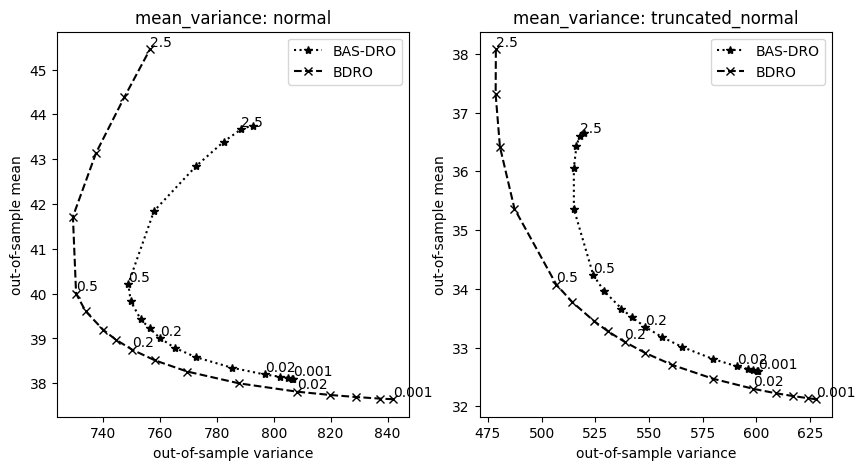

In [4]:
fig, axes = flexible_figure(agg_df, "mean_variance", compare_col="algorithm", gb_col="dgp", ncols=2)
fig.show()

## Solve time

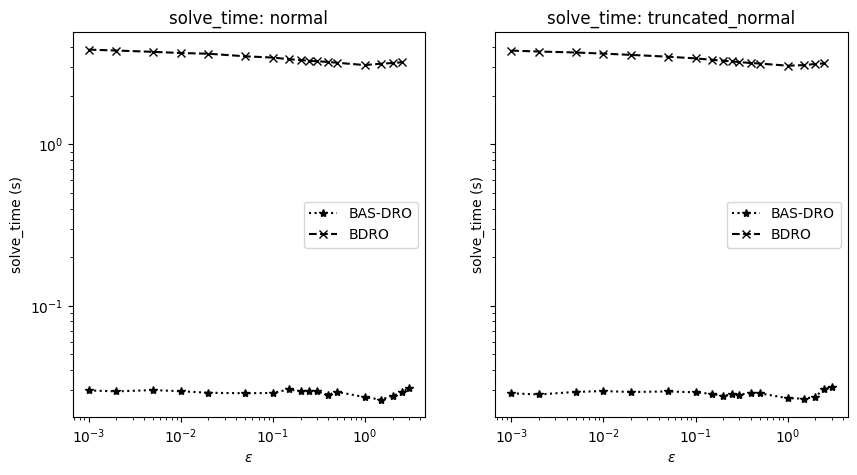

In [5]:
fig, axes = flexible_figure(agg_df, "solve_time", compare_col="algorithm", gb_col="dgp", sharex=True, sharey=True, ncols=2)
fig.show()